# Build your own Google Photos — reference walkthrough

This is the reference solution for **Project 3**. It runs the full pipeline on a small
**demo set: 92 photos, 11 categories**, fetched from the web (Khustup, Lake Sevan, shawarma,
khorovats, cheese, potato, pomegranate, duduk, khachkar, the Cascade, Armenian folk dance).
The photos went through **the same given scripts you will use**: the folder was embedded with
`py_src/embed_my_photos.py`, and the interactive maps come from `py_src/photo_map.py`.

Two things to know before reading:

- **Your project runs on *your* photos.** Every number below (how many clusters, which
  categories merge, what the metric says) will be different for your collection —
  so copying this notebook wholesale cannot produce your project.
- One category pair was **planted as a trap**: khorovats and shawarma are both close-up
  grilled meat. Watch what the pipeline does with them.

In [1]:
import io
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)

SEED = 509
rng = np.random.default_rng(SEED)

os.makedirs("out", exist_ok=True)
ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"
plt.rcParams["figure.dpi"] = 110

In [2]:
# this npz was written by the given script -- the exact command you run on YOUR folder:
#     python py_src/embed_my_photos.py data/demo_photos
# (how the embedding is computed is shown live in section 1, once the model is loaded)
data = np.load("data/demo_photos_clip.npz")

X = data["embeddings"].astype(np.float32)      # (92, 512) CLIP image vectors, unit length
names = [str(s) for s in data["filenames"]]
blob, offsets = data["thumb_blob"], data["thumb_offsets"]

# the category is the filename prefix (khorovats_03.jpg -> "khorovats"); on YOUR photos
# there is no such luxury -- you hand-annotate a subset, exactly as the task list says
labels = [s.rsplit("_", 1)[0] for s in names]
cats = sorted(set(labels))
y = np.array([cats.index(l) for l in labels])
n = len(names)

print(f"photos    : {n}")
print(f"embedding : {X.shape[1]} numbers per photo, from {str(data['model_id'])}")
print(f"categories: {len(cats)}")
for c in cats:
    print(f"  {c:12s} {labels.count(c):2d} photos")


def thumb(i):
    """Decode the i-th cached thumbnail (128x128 JPEG) into an array."""
    return np.asarray(Image.open(io.BytesIO(blob[offsets[i]:offsets[i + 1]].tobytes())))

photos    : 92
embedding : 512 numbers per photo, from openai/clip-vit-base-patch32
categories: 11
  cascade       9 photos
  cheese        6 photos
  duduk        10 photos
  folkdance     7 photos
  khachkar      9 photos
  khorovats    10 photos
  khustup       8 photos
  pomegranate  10 photos
  potato        6 photos
  sevan         8 photos
  shawarma      9 photos


A quick look, so you know what we are working with — these 92 photos are the only
pictures in this notebook:

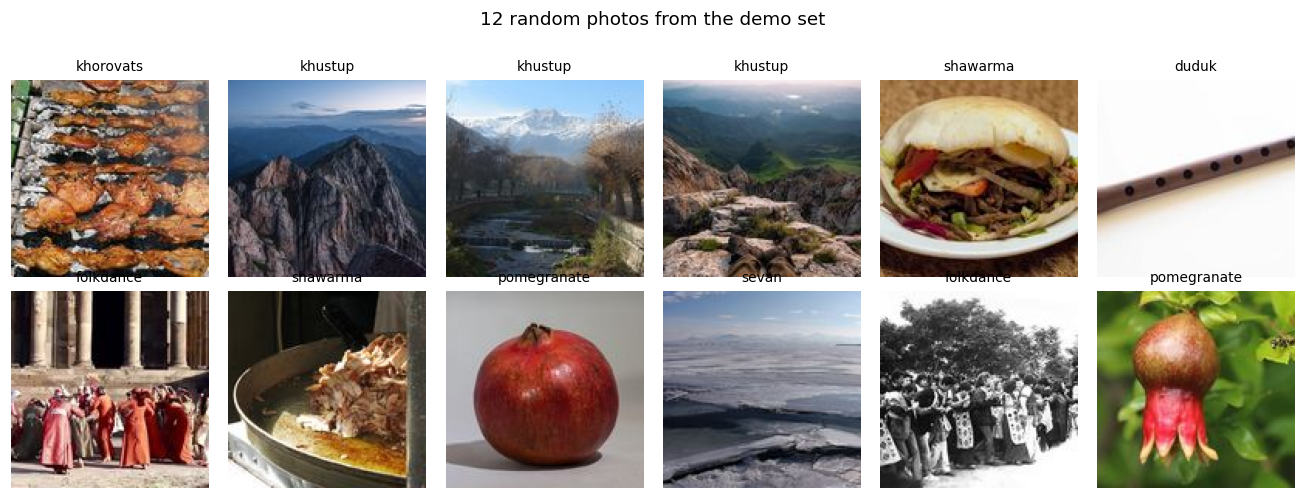

In [3]:
sample = rng.choice(n, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for ax, i in zip(axes.ravel(), sample):
    ax.imshow(thumb(i))
    ax.set_title(labels[i], fontsize=9)
    ax.axis("off")
fig.suptitle("12 random photos from the demo set", y=1.02)
plt.tight_layout()
plt.show()

## 1. Meet CLIP — and play with it before any clustering

CLIP (OpenAI, 2021) is two encoders trained together on 400 million (image, caption)
pairs: one turns an **image** into 512 numbers, the other turns a **text** into 512
numbers, and training pushes matching pairs together. The consequence is the whole
point of this project: **photos and words live in the same space**, so you can compare
a photo to a word with a plain dot product.

The model's full name, `openai/clip-vit-base-patch32`, unpacks as: **CLIP** =
Contrastive Language-Image Pre-training; **ViT** = Vision Transformer, the
architecture of the image encoder; **base** = the size tier (a bigger `large` exists);
**patch32** = the image is cut into 32x32-pixel patches that the transformer reads
like words in a sentence.

The image side already ran in bulk (that is what `embed_my_photos.py` did). We load
the model once more anyway: first to replay that recipe on a single photo so you see
what the script actually does, then for its **text** encoder — and spend a few cells
just playing, because the tricks below are what make the clustering later feel
inevitable rather than magical.

In [4]:
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import torch
from transformers import CLIPModel, CLIPProcessor

t0 = time.time()
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
print(f"model loaded in {time.time() - t0:.0f}s "
      "(first ever run also downloads ~600 MB)")


def embed_text(texts):
    """List of strings -> (len, 512) unit-length CLIP text vectors."""
    inputs = processor(text=texts, return_tensors="pt", padding=True)
    with torch.no_grad():
        t = model.get_text_features(**inputs).pooler_output
    return (t / t.norm(dim=-1, keepdim=True)).numpy().astype(np.float32)

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model loaded in 5s (first ever run also downloads ~600 MB)


### The embedding call itself, on one photo

Loading an npz is not an explanation. Here is the complete recipe that turns a photo
into 512 numbers — the same lines `py_src/embed_my_photos.py` runs in a loop over the
whole folder (batched, plus thumbnails) — replayed on one photo and checked against
the row stored in the npz:

In [5]:
img = Image.open("data/demo_photos/sevan_12.jpg").convert("RGB")
inputs = processor(images=[img], return_tensors="pt")  # CLIP's own preprocessing: resize + center-crop to 224x224
with torch.no_grad():
    vec = model.get_image_features(**inputs).pooler_output[0]
vec = (vec / vec.norm()).numpy()                       # unit length, like the npz

stored = X[names.index("sevan_12.jpg")]
print(f"{img.size[0]}x{img.size[1]} pixels -> {vec.shape[0]} numbers; first five: {np.round(vec[:5], 3)}")
print(f"dot product with the npz row: {vec @ stored:.6f}  (float16 storage -> the stored row is not exactly unit length)")

960x1280 pixels -> 512 numbers; first five: [ 0.029 -0.008  0.019  0.017  0.006]


dot product with the npz row: 1.000019  (float16 storage -> the stored row is not exactly unit length)


### 1a. Search your photos with words

The Google Photos moment: type a word, rank all 92 photos by dot product with the
word's vector, show the top 3. No training, no labels, no code beyond a matrix
multiply.

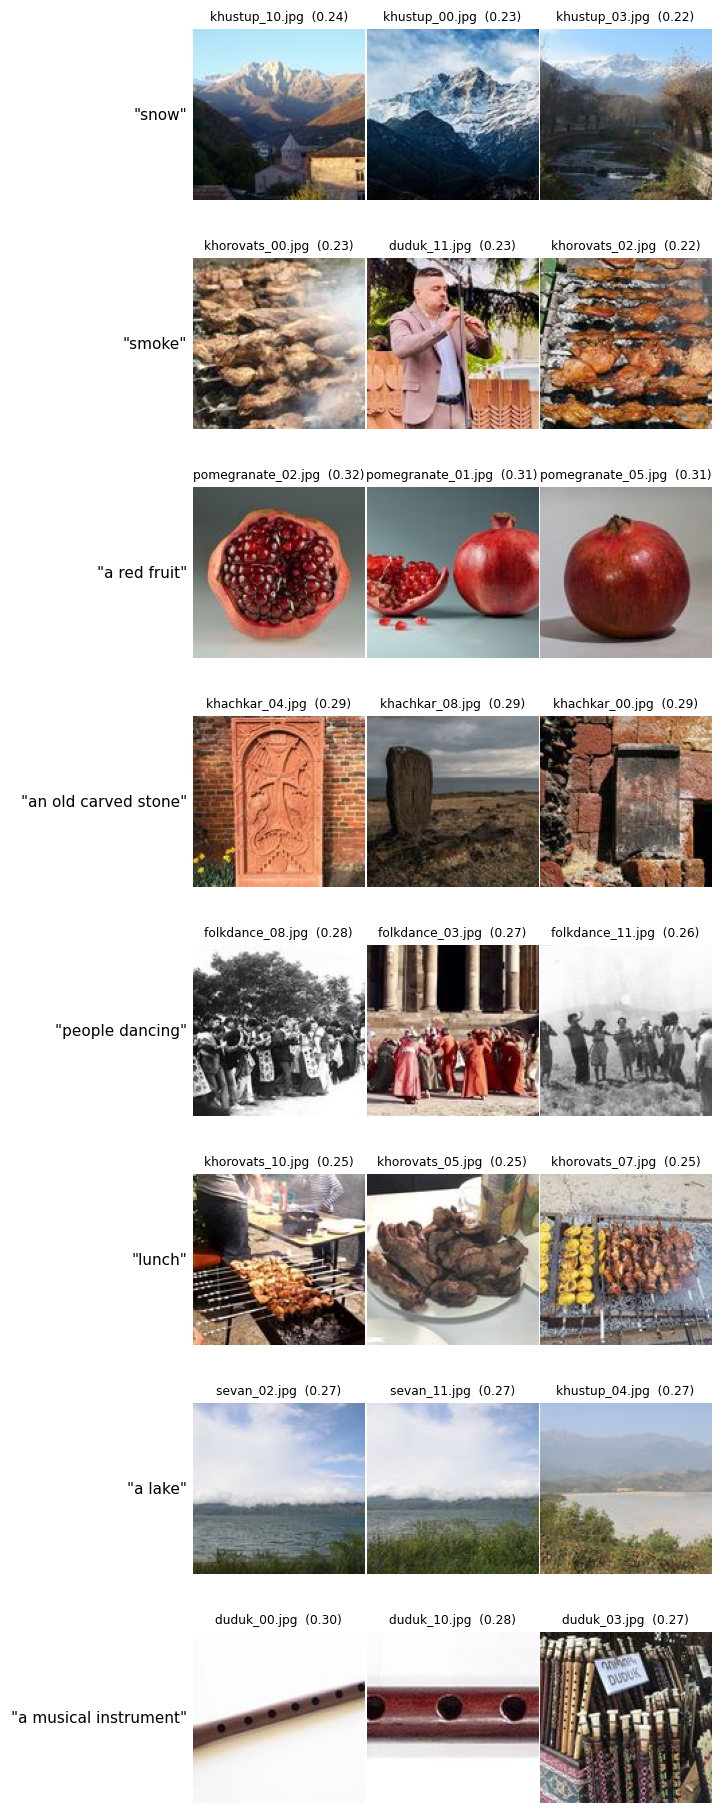

In [6]:
queries = ["snow", "smoke", "a red fruit", "an old carved stone",
           "people dancing", "lunch", "a lake", "a musical instrument"]
TQ = embed_text(queries)

fig, axes = plt.subplots(len(queries), 3, figsize=(6.6, 2.1 * len(queries)))
for r, (q, tvec) in enumerate(zip(queries, TQ)):
    top = np.argsort(-(X @ tvec))[:3]
    for c_, i in enumerate(top):
        ax = axes[r, c_]
        ax.imshow(thumb(i))
        ax.set_title(f"{names[i]}  ({X[i] @ tvec:.2f})", fontsize=8)
        ax.axis("off")
    axes[r, 0].set_ylabel(f'"{q}"', rotation=0, ha="right", va="center", fontsize=10)
    axes[r, 0].axis("on")
    axes[r, 0].set_xticks([]), axes[r, 0].set_yticks([])
    for s in axes[r, 0].spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

Seven of the eight queries land cleanly: "snow" finds the snowy Khustup shots,
"lunch" finds khorovats, "a lake" finds Sevan. The eighth is an honest miss worth
keeping: "smoke" ranks a duduk performer second. You can stare at that photo and
guess what the model latched onto, but the truth is we do not know -- that opacity is
part of working with learned embeddings. ("People dancing" surfacing the two
black-and-white archive photos first is not a miss: dancing is dancing, whatever the
decade.)

One honest note before you over-trust the numbers in the titles: cross-modal
similarities are **small** (about 0.2-0.3) even for perfect matches, because image
vectors and text vectors occupy two different regions of the space (the *modality
gap*). Absolute values mean little -- **rankings** are what work.

### 1b. Vector arithmetic across modalities

The classic word2vec party trick was *king − man + woman ≈ queen*. The CLIP version is
better, because you can mix photos and words. The recipe: take two piles of photos
that differ by **one thing**, subtract their average vectors, and ask which *word* the
difference points at.

Our built-in pair: **Sevan photos are mountains *with a lake***, **Khustup photos are
mountains *without* one**. So `mean(sevan) − mean(khustup)` should be, roughly, the
direction that means "lake" — a vector no photo and no word produced directly.

In [7]:
bank = ["lake", "water", "sea", "mountain", "snow", "rock", "cliff", "monastery",
        "church", "cross", "stone", "carving", "meat", "barbecue", "skewers",
        "grill", "wrap", "sandwich", "bread", "lavash", "cheese", "potato",
        "fruit", "pomegranate", "red", "dance", "dancing", "costume", "music",
        "flute", "instrument", "stairs", "staircase", "city", "fountain",
        "sculpture", "people", "crowd", "smoke", "grass"]
TB = embed_text(bank)

cent = np.vstack([X[y == i].mean(axis=0) for i in range(len(cats))])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)


def nearest_words(vec, k=4):
    vec = vec / np.linalg.norm(vec)
    return [bank[i] for i in np.argsort(-(TB @ vec))[:k]]


pairs = [("sevan", "khustup"), ("khustup", "sevan"),
         ("shawarma", "khorovats"), ("khorovats", "shawarma"),
         ("folkdance", "duduk"), ("pomegranate", "potato")]
for a, b in pairs:
    diff = cent[cats.index(a)] - cent[cats.index(b)]
    print(f"mean({a}) - mean({b})  ->  " + ", ".join(nearest_words(diff)))

mean(sevan) - mean(khustup)  ->  sea, lake, water, costume
mean(khustup) - mean(sevan)  ->  mountain, stairs, pomegranate, staircase
mean(shawarma) - mean(khorovats)  ->  lavash, sandwich, wrap, bread
mean(khorovats) - mean(shawarma)  ->  barbecue, skewers, grill, lake
mean(folkdance) - mean(duduk)  ->  dance, dancing, crowd, pomegranate
mean(pomegranate) - mean(potato)  ->  pomegranate, red, fruit, fountain


Read those again, they are worth it:

- **sevan − khustup → sea, lake, water** and the reverse points at **mountain**.
  Subtracting photos isolated the *one thing that differs*, and the nearest object in
  the space turned out to be a word.
- **shawarma − khorovats → lavash, sandwich, wrap**: the difference between the two
  grilled-meat categories is literally *the bread around it* — which is also exactly
  why they will give the clustering trouble later.
- **folkdance − duduk → dance, dancing**: same performers, same costumes; what differs
  is the activity.

This is the "person with sunglasses − person without ≈ *sunglasses*" structure, built
from our own photo folder. It only works because both modalities share one space.

### 1c. Algebra as search: photo + word → photo

One more, in the other direction: take the average **Khustup** photo, *add* the word
**"a lake"**, and ask which photo is now closest (excluding Khustup itself).

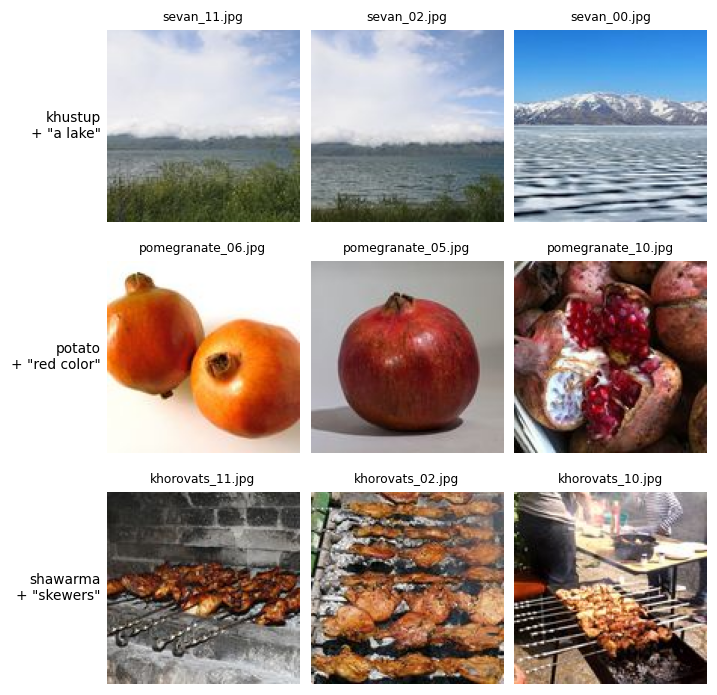

In [8]:
combos = [("khustup", "a lake"), ("potato", "red color"), ("shawarma", "skewers")]
fig, axes = plt.subplots(len(combos), 3, figsize=(6.6, 2.15 * len(combos)))
for r, (cat, word) in enumerate(combos):
    q = cent[cats.index(cat)] + embed_text([word])[0]
    q /= np.linalg.norm(q)
    order = [i for i in np.argsort(-(X @ q)) if labels[i] != cat][:3]
    for c_, i in enumerate(order):
        axes[r, c_].imshow(thumb(i))
        axes[r, c_].set_title(names[i], fontsize=8)
        axes[r, c_].axis("off")
    axes[r, 0].set_ylabel(f"{cat}\n+ \"{word}\"", rotation=0, ha="right",
                          va="center", fontsize=9)
    axes[r, 0].axis("on")
    axes[r, 0].set_xticks([]), axes[r, 0].set_yticks([])
    for s in axes[r, 0].spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

Mountain + "a lake" retrieves **Sevanavank**. Potato + "red color" retrieves
**pomegranates**. Shawarma + "skewers" retrieves **khorovats**. Arithmetic on vectors
behaves like *editing the meaning of a query*.

That is the end of the playground, and the setup for everything below: distances in
this 512-dimensional space track **what is in the photo**, not what color it is. So an
algorithm as dumb as k-means, fed these vectors, should group photos by content. Let's
verify — starting with proof that it does *not* work without CLIP.

## 2. The obvious approach, and why it fails

Flatten each 128×128 thumbnail into 49,152 raw pixel values and k-means that.

In [9]:
thumbs_arr = np.stack([thumb(i) for i in range(n)])
pixels = thumbs_arr.reshape(n, -1).astype(np.float32) / 255.0

km_pix = KMeans(n_clusters=len(cats), n_init=10, random_state=SEED).fit(pixels)
print(f"pixels     : {pixels.shape[1]:,} dims")
print(f"ARI vs true: {adjusted_rand_score(y, km_pix.labels_):.3f}   "
      f"AMI: {adjusted_mutual_info_score(y, km_pix.labels_):.3f}   (chance = 0)")

pixels     : 49,152 dims
ARI vs true: 0.063   AMI: 0.138   (chance = 0)


ARI ≈ **0.06**. Not a near miss — a total failure. Two khorovats photos, one on a
sunny table and one over dark coals, are *far apart* in pixel space; a snowy Khustup
and a white cheese wheel are *close*. Pixels measure light, not content. (This is the
same experiment you are asked to run as task 2, and the gap you should report.)

The embeddings from `embed_my_photos.py` come **already unit-length** (the script
normalizes before saving), so there is no normalize-or-not decision to make here —
dot product and cosine are the same thing for these vectors.

## 3. How many clusters does the *data* think there are?

We know the answer is 11 — we planted the categories. Pretend we don't, like on your
own photos, and sweep k with the silhouette score.

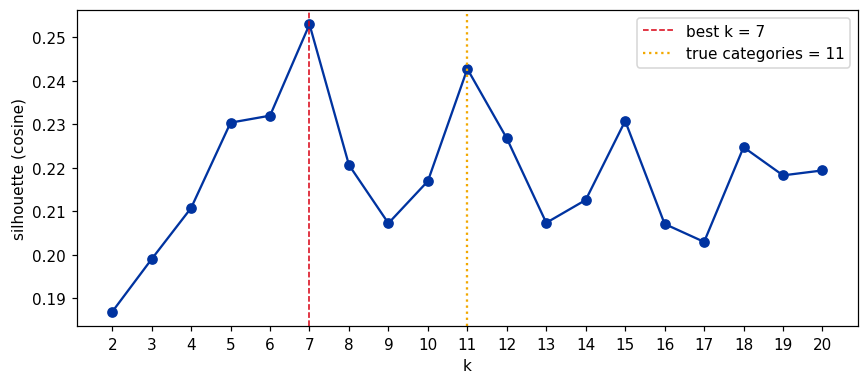

best k = 7, silhouette 0.253; at k=11 it is 0.243


In [10]:
k_values = list(range(2, 21))
sil = []
for k in k_values:
    lab = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    sil.append(silhouette_score(X, lab, metric="cosine"))

best_k = k_values[int(np.argmax(sil))]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(k_values, sil, "o-", color=ARM_BLUE)
ax.axvline(best_k, color=ARM_RED, ls="--", lw=1, label=f"best k = {best_k}")
ax.axvline(11, color=ARM_ORANGE, ls=":", lw=1.5, label="true categories = 11")
ax.set_xlabel("k"), ax.set_ylabel("silhouette (cosine)")
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.show()
print(f"best k = {best_k}, silhouette {max(sil):.3f}; at k=11 it is {sil[k_values.index(11)]:.3f}")

The silhouette votes **k = 7**, with a local bump at 11. It is not wrong: at k=7 the
food categories genuinely form fewer geometric blobs than we have names for (the trap
pair is one blob, and it is right about that). The metric sees **geometry**; it cannot
see that your labeling intent is finer than the geometry. On your photos, treat the
silhouette as a guide to *plausible* k values, look at 2–3 of them, and say in your
report why you picked yours. We proceed with k = 11 because we know the ground truth
— a luxury you will only partly have.

In [11]:
km = KMeans(n_clusters=11, n_init=10, random_state=SEED).fit(X)
clusters = km.labels_
print(f"k=11 on embeddings -> ARI {adjusted_rand_score(y, clusters):.3f}, "
      f"AMI {adjusted_mutual_info_score(y, clusters):.3f}")

k=11 on embeddings -> ARI 0.647, AMI 0.756


**ARI 0.65** from the same k-means that scored 0.06 on pixels. Same algorithm, same
photos — the only change is the representation. This is the single most important
sentence of the project.

## 4. Let the clusters name themselves

Multimodality, pass two. Each k-means cluster has a centroid — an *image*-side vector.
Our word bank lives on the *text* side of the same space. Nearest word to each
centroid = a free label, no human in the loop.

In [12]:
Xn = X  # already unit length
rows = []
cluster_word = {}
for c in range(11):
    m = clusters == c
    centre = Xn[m].mean(axis=0)
    centre /= np.linalg.norm(centre)
    sims = TB @ centre
    top = np.argsort(-sims)[:3]
    cluster_word[c] = bank[top[0]]
    true_top = pd.Series([labels[i] for i in np.where(m)[0]]).mode()[0]
    rows.append({"cluster": c, "size": int(m.sum()), "name from text": bank[top[0]],
                 "similarity": float(sims[top[0]]), "runner-up": bank[top[1]],
                 "mostly (from filenames)": true_top})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

 cluster  size name from text  similarity runner-up mostly (from filenames)
       0     8      sculpture       0.307     cross                khachkar
       1     7         potato       0.322     fruit                  potato
       2    19        skewers       0.296  barbecue               khorovats
       3    10           lake       0.283       sea                   sevan
       4    11    pomegranate       0.341     fruit             pomegranate
       5     7         lavash       0.281     flute               folkdance
       6     2          crowd       0.263    people               folkdance
       7     9       fountain       0.286 sculpture                 cascade
       8     5          flute       0.307     music                   duduk
       9     7       mountain       0.290 monastery                 khustup
      10     7         cheese       0.280    lavash                  cheese


Nine of eleven names are exactly what a person would say: *sculpture/cross* for the
khachkars, *fountain* for the Cascade, *flute* for the duduks, *mountain*, *lake*,
*cheese*, *pomegranate*, *potato* — and the big 19-photo cluster honestly calls itself
**skewers**, because it is the khorovats+shawarma merger. The misses are instructive
too: one small folk-dance cluster gets named *lavash* — auto-naming is only as good as
the word bank you offer it (ours has 40 words; add better candidate words and the name
improves). Bonus experiment for your report: zero-shot classify every photo against
your own category names, and compare phrasings — with full sentence prompts
("a khachkar, an Armenian carved cross-stone") we measured **97.8%** accuracy on this
set; with bare single words only **65%**. Prompt wording is part of the model input.

## 5. The map — normal scatter first, then the given hover map

Task 5 of the project, demonstrated: project to 2-D, make the ordinary matplotlib
scatter yourself, and only then hand the *same* coordinates to the provided
`make_photo_map`. PCA first (honest, linear), UMAP second (prettier, remember lecture
36 before you trust it).

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


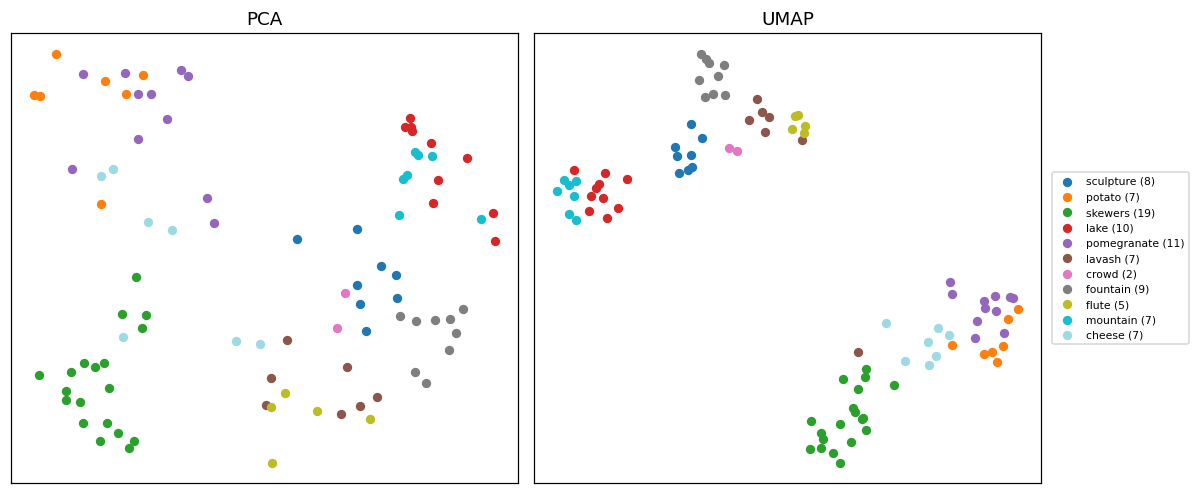

In [13]:
sys.path.insert(0, ".")
from py_src.photo_map import jpegs_from_npz, make_photo_map
import umap

Z_pca = PCA(n_components=2, random_state=SEED).fit_transform(X)
Z_umap = umap.UMAP(n_components=2, metric="cosine", random_state=SEED).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
palette = plt.get_cmap("tab20")(np.linspace(0, 1, 11))
for ax, Z, ttl in [(axes[0], Z_pca, "PCA"), (axes[1], Z_umap, "UMAP")]:
    for c in range(11):
        m = clusters == c
        ax.scatter(Z[m, 0], Z[m, 1], s=26, color=palette[c],
                   label=f"{cluster_word[c]} ({m.sum()})")
    ax.set_title(ttl)
    ax.set_xticks([]), ax.set_yticks([])
axes[1].legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

In [14]:
jpegs = jpegs_from_npz(data)
gnames = {c: cluster_word[c] for c in range(11)}
make_photo_map(Z_pca, jpegs, hover_names=names, groups=clusters, group_names=gnames,
               title="Demo set -- PCA (clusters named by CLIP text)",
               out_html="out/demo_photos_map_pca.html")
make_photo_map(Z_umap, jpegs, hover_names=names, groups=clusters, group_names=gnames,
               title="Demo set -- UMAP (clusters named by CLIP text)",
               out_html="out/demo_photos_map_umap.html")
print("open out/demo_photos_map_pca.html and out/demo_photos_map_umap.html in a browser")

open out/demo_photos_map_pca.html and out/demo_photos_map_umap.html in a browser


Hover the PCA map around the *skewers* region: khorovats and shawarma interleave —
PCA shows the overlap because it is really there in the 512-d space. UMAP carves neat
separated islands out of the same points, **including** splitting things that overlap.
Pretty is not the same as true (lecture 36; Chari & Pachter 2023). Show both in your
project and say which claim each one supports.

## 6. Score against the truth, and find the story

Filename prefixes give us full ground truth, so we can afford the full crosstab. On
your photos you will have this only for the subset you annotated — the ARI/AMI recipe
is identical.

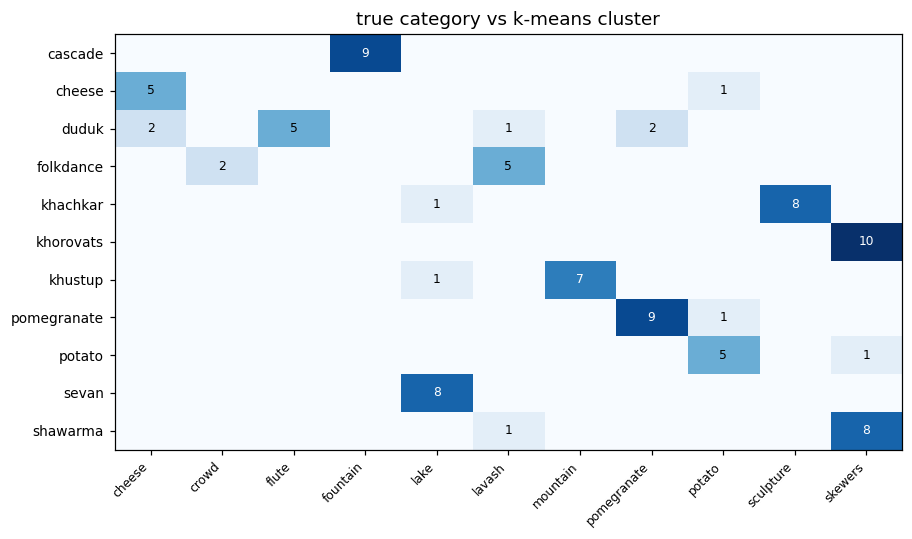

In [15]:
ct = pd.crosstab(pd.Series(labels, name="true category"),
                 pd.Series([cluster_word[c] for c in clusters], name="cluster (auto-named)"))
fig, ax = plt.subplots(figsize=(8.4, 5))
ax.imshow(ct.values, cmap="Blues", aspect="auto", vmax=ct.values.max())
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(ct.shape[0]), ct.index, fontsize=9)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8,
                    color="white" if v > ct.values.max() * 0.6 else "black")
ax.set_title("true category vs k-means cluster")
plt.tight_layout()
plt.show()

Almost diagonal, with one big exception — and it is the planted one: the **skewers**
cluster holds all 10 khorovats **and** 8 of 9 shawarma. CLIP sees "close-up of grilled
meat" in both; the thing that separates them is a word (*wrap*), not a look — we even
recovered that word by vector arithmetic in section 1b. The genes practical had the
same lesson (ASW/ACB sit with AFR because ancestry, not residence, is what DNA
records): **an embedding is honest about what it measures, and your labels can carry
information the signal does not.**

The smaller smudges are worth a sentence each in a report: a couple of duduk photos
land with *cheese* and *pomegranate* (market-stall scenes), one potato photo sits with
the food cluster.

## Wrap-up — what this means for *your* project

| Project task | What we saw here (92 web photos) | What to expect on yours |
|---|---|---|
| 1. embed your folder | `embed_my_photos.py`, unchanged | same, plus HEIC just works |
| 2. raw pixels baseline | ARI 0.06 | a similar faceplant — report it |
| 3. cluster embeddings | ARI 0.65 at k=11 | roughly 0.4–0.7 on hand labels |
| 4. choose k | silhouette said 7, truth was 11 | disagreement is normal; discuss it |
| 5. scatter + hover map | PCA honest, UMAP pretty | show both, trust carefully |
| extra: text side | search, arithmetic, auto-names | the fun part — use `embed_text` |

The best paragraph of your report is probably not the ARI. It is your version of the
*skewers* cluster: the pair of categories from **your** life that CLIP refuses to
separate, and the sentence explaining what that says about how it sees.